# Numerical Simulation Laboratory - Exercise 1


## INTRODUCTION


In this first exercise some basic tools of Monte Carlo simulations are studied: pseudo-random number generation, sampling from assigned probability distributions, progressive estimates of statistical uncertainties, and simple tests of compatibility with theoretical expectations.

Monte Carlo methods are numerical techniques based on random sampling. Instead of solving a problem deterministically, they estimate the desired quantity by generating many random events and averaging the corresponding outcomes. For this reason, Monte Carlo estimates are affected by statistical fluctuations, and their reliability depends on the number of sampled data and on a correct estimate of the statistical uncertainty.

The starting point is the pseudo-random number generator `Rannyu()`, which produces numbers uniformly distributed in the interval $[0,1)$. From this generator it is possible to construct other probability distributions, for instance by using the inversion of the cumulative distribution function.

A central point of the exercise is that a Monte Carlo result is not only a number: it must also be accompanied by a reliable estimate of its statistical uncertainty. For this reason, the results are analyzed with the **data blocking** technique.

### Data Blocking

In **data blocking**, the full set of Monte Carlo throws is divided into $N$ blocks, each containing the same number of data. An average value is first computed inside each block, and these block averages are then treated as effective measurements of the same quantity.

This procedure is useful because it allows the statistical **uncertainty** to be estimated directly from the simulation. It also provides a progressive estimate of the measured quantity, making it possible to check whether the result stabilizes as more blocks are included.

Data blocking is also important because Monte Carlo data are not always strictly independent. In this exercise the numbers are generated by `Rannyu()`, a deterministic pseudo-random number generator designed to reproduce independent uniform random variables. Since pseudo-random sequences are not truly random, their statistical properties must be checked through tests such as the ones performed below. More generally, in Monte Carlo simulations based on successive configurations, consecutive samples can be **correlated**. If the blocks are chosen large enough, short-range correlations are mostly averaged inside each block, so that different block averages can be treated as approximately independent measurements.

### Central Limit Theorem

The **Central Limit Theorem** explains why Gaussian distributions appear so often in Monte Carlo simulations. If $x_1,x_2,\dots,x_N$ are independent random variables drawn from the same distribution, with finite mean $\mu$ and finite variance $\sigma^2$, then the average

$$
S_N=\frac{1}{N}\sum_{i=1}^{N}x_i
$$

becomes approximately Gaussian distributed when $N$ is large. The center of the distribution tends to $\mu$, while its width decreases as $1/\sqrt{N}$.

This theorem is important in the exercise because the distributions of the averages $S_N$ are studied for different values of $N$. For the uniform and exponential distributions, which have finite mean and variance, the histograms are expected to approach a Gaussian shape. The Lorentzian distribution is an exception: it does not have a finite variance, so the standard Central Limit Theorem does not apply, and the average $S_N$ remains Lorentzian-distributed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2, norm, cauchy

# Files produced by the C++ codes
data = pd.read_csv("Results/Esercizio_01.1_results.txt", sep=";")
chi2_data = pd.read_csv("Results/Esercizio_01.1_chi2_results.txt", sep=";")
chi2_additional_data = pd.read_csv("Results/Esercizio_01.1_chi2_additional_results.txt", sep=";")
data_2 = pd.read_csv("Results/Esercizio_01.2_results.txt", sep=";")
data_3 = pd.read_csv("Results/Esercizio_01.3_results.txt", sep=";")


## EXERCISE 1.1


### Assignment prompt


**Exercise 01.1** - Test the Pseudo-Random Number generator downloaded from the NSL Ariel web site by estimating:

1. $
\langle r \rangle = \int_0^1 r\,dr = 1/2
$. Make a picture of the estimation of $\langle r \rangle$ and its uncertainty, with a large number of throws $M$ as a function of the number of blocks $N$.

2. $
\sigma^2 = \int_0^1 (r-1/2)^2\,dr = 1/12
$. Make a picture of the estimation of $\sigma^2$ and its uncertainty, with a large number of throws $M$ as a function of the number of blocks $N$.

3. Divide $[0,1]$ into $M=10^2$ identical sub-intervals and implement the $\chi^2$ test. Use $n=10^4$ pseudo-random numbers, repeat the test 100 times and plot $\chi^2_j$ for $j=1,\dots,100$. Compare also the histogram of the obtained $\chi^2_j$ values with the expected $\chi^2$ distribution.


### Method


The goal is to check whether the pseudo-random numbers produced by the generator are compatible with a uniform distribution in $[0,1)$. Of course, a deterministic generator cannot be proven to be truly random. It is only possible to test whether some statistical properties of the generated sequence agree with the properties expected for independent uniform random variables.

For the first two requests, $M=10000$ throws are divided into $N=100$ blocks, so that each block contains 100 throws. For each block, a block estimate of the observable is computed. Progressive averages and progressive uncertainties are then obtained by applying the data blocking method to the block estimates.

The central part of the C++ code used for the **block averages** is:

```cpp
for(int i=0; i<N_blocks; i++){
   double sum = 0.0;
   for(int j=0; j<throws_per_block; j++){
      block_throws[j] = rnd.Rannyu();
      sum += block_throws[j];
   }
   data[i] = sum/throws_per_block;
   data_2[i] = data[i]*data[i]; 
}
```

#### Application of Data blocking


The block estimates are used to compute progressive averages and progressive uncertainties. In Monte Carlo simulations the exact expectation value is usually unknown, so both the estimate and its statistical uncertainty must be obtained from the sampled data.

If $A_i$ is the estimate obtained from block $i$, the progressive average after $n+1$ blocks is

$$
\langle A \rangle_n = \frac{1}{n+1}\sum_{i=0}^{n} A_i,
$$

and the corresponding progressive average of the squared block estimates is

$$
\langle A^2 \rangle_n = \frac{1}{n+1}\sum_{i=0}^{n} A_i^2.
$$

The uncertainty on the progressive average is then estimated as

$$
\sigma_{\langle A \rangle}(n)=
\sqrt{\frac{\langle A^2\rangle_n - \langle A\rangle_n^2}{n}}.
$$

This is the progressive version of the blocking formula: after $n+1$ blocks, the number of block estimates is $N_b=n+1$, so the factor $N_b-1$ becomes $n$.

The uncertainty is computed progressively because it allows one to monitor the convergence of the simulation. As more blocks are included, both the average value and its statistical uncertainty should stabilize. This is a useful check that the number of sampled data is large enough and that the final estimate is statistically reliable.

In the first block the error cannot be estimated from a single block value, so it is conventionally set to zero.

The **progressive estimates** are built in the code by using, for each value of `i`, only the first `i+1` block estimates. The factor `i+1` appears because the block index starts from zero: when `i=0` only the first block is included, when `i=1` the first two blocks are included, and so on.

```cpp
for(int i=0; i<N_blocks; i++){

   double sum_prog = 0.0;
   double sum2_prog = 0.0;

   for(int j=0; j<i+1; j++){
      sum_prog += data[j];
      sum2_prog += data_2[j];
   }

   progressive_mean[i] = sum_prog/(i+1);
   progressive_mean_2[i] = sum2_prog/(i+1);
   progressive_error[i] = error(progressive_mean, progressive_mean_2, i);
}
```

The C++ function used to compute the progressive uncertainty is:

```cpp
double error(double avg[], double avg2[], int n){
   if(n == 0){
      return 0.0;
   } else {
      return sqrt((avg2[n] - pow(avg[n],2))/n);
   }
}
```

### 1.1.1) Progressive estimate of $\langle r \rangle$


For a uniform distribution in $[0,1)$, the expected value is

$$
\langle r \rangle = \int_0^1 r\,dr = \frac{1}{2}.
$$

The following plot shows the progressive estimate of $\langle r \rangle$ with its statistical uncertainty as a function of the total number of throws included in the estimate.


#### Results


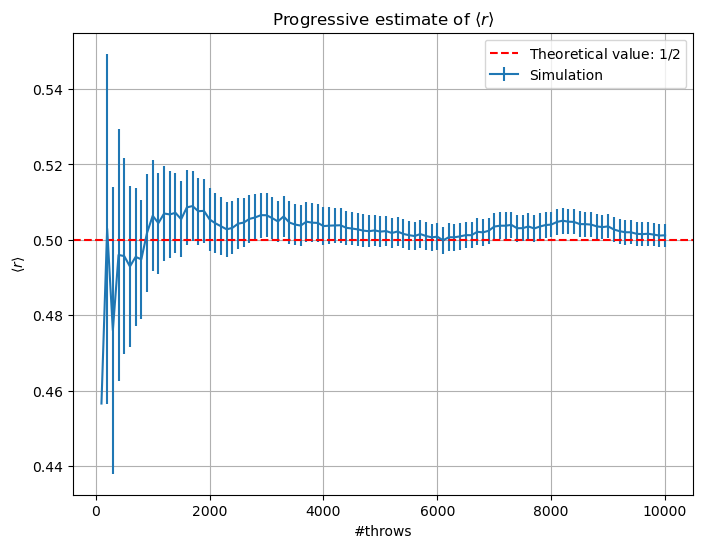

Final estimate: <r> = 0.501214 ± 0.003067


In [2]:
N_throws = 10000
N_blocks = 100
throws_per_block = N_throws // N_blocks

x_blocks = np.arange(1, N_blocks+1) * throws_per_block

plt.figure(figsize=(8, 6))
plt.title(r"Progressive estimate of $\langle r \rangle$")
plt.errorbar(x_blocks, data["Progressive_mean"], yerr=data["Progressive_error"], label="Simulation")
plt.axhline(y=1/2, color='r', linestyle='--', label=r'Theoretical value: $1/2$')
plt.xlabel('#throws')
plt.ylabel(r'$\langle r \rangle$')
plt.grid(True)
plt.legend()
plt.show()

print(f"Final estimate: <r> = {data['Progressive_mean'].iloc[-1]:.6f} ± {data['Progressive_error'].iloc[-1]:.6f}")


#### Comment


The final estimate is compatible with the theoretical value $1/2$ within the statistical uncertainty. The plot also shows the typical behavior of a progressive Monte Carlo estimate: as the number of blocks increases, the estimate fluctuates less and stabilizes around the expected value, while the error bar decreases.


### 1.1.2) Progressive estimate of $\sigma^2$


The second requested quantity is

$$
\sigma^2 = \int_0^1 \left(r-\frac{1}{2}\right)^2 dr = \frac{1}{12}.
$$

In the C++ code, the variance is first estimated inside each block. In this implementation, the deviations are not computed with respect to the theoretical mean \(1/2\), but with respect to the mean of the current block, stored in `data[i]`.

The relevant part of the code is:

```cpp
for(int i=0; i<N_blocks; i++){

   double sum_var = 0.0;

   for(int j=0; j<throws_per_block; j++){
      // data[i] is the mean of the current block, computed above
      sum_var += pow(block_throws[j] - data[i], 2);
   }

   variance[i] = sum_var/(throws_per_block-1);
   variance_2[i] = pow(variance[i], 2);
}
```

The division by `throws_per_block-1` accounts for the loss of one degree of freedom, since the block mean is estimated from the data themselves. Then, the same progressive blocking analysis described in the previous point is applied to the block variances.

#### Results


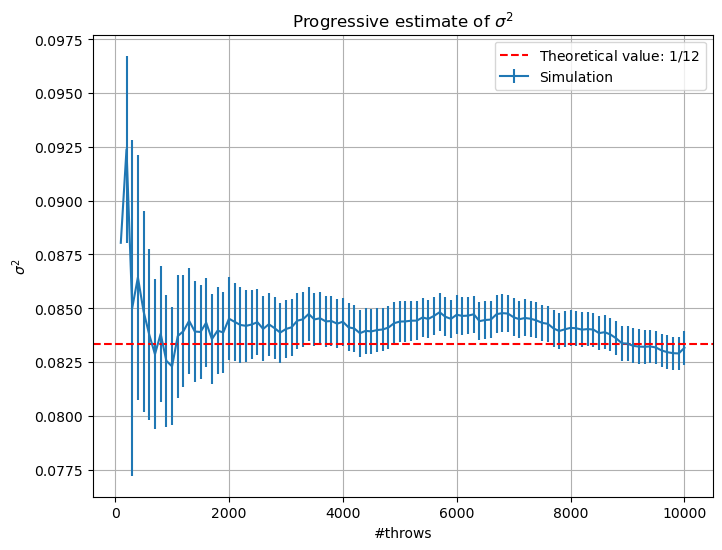

Final estimate: sigma^2 = 0.083163 ± 0.000801
Theoretical value: 1/12 = 0.083333


In [3]:
N_throws = 10000
N_blocks = 100
throws_per_block = N_throws // N_blocks

plt.figure(figsize=(8, 6))
plt.title(r"Progressive estimate of $\sigma^2$")
plt.errorbar(x_blocks, data["Progressive_variance"], yerr=data["Progressive_variance_error"], label="Simulation")
plt.axhline(y=1/12, color='r', linestyle='--', label=r'Theoretical value: $1/12$')
plt.xlabel('#throws')
plt.ylabel(r'$\sigma^2$')
plt.grid(True)
plt.legend()
plt.show()

print(f"Final estimate: sigma^2 = {data['Progressive_variance'].iloc[-1]:.6f} ± {data['Progressive_variance_error'].iloc[-1]:.6f}")
print(f"Theoretical value: 1/12 = {1/12:.6f}")


#### Comment


The estimated variance is compatible with the theoretical value $1/12 \simeq 0.08333$. This is a second check of the generator: it reproduces not only the expected mean value of a uniform distribution, but also its expected spread.


### 1.1.3) $\chi^2$ test


#### Method


For the $\chi^2$ test, the interval $[0,1]$ is divided into

$$
M = 100
$$

equal bins. In each test, the generator produces

$$
n = 10^4
$$

pseudo-random numbers. If the numbers are uniformly distributed, each bin should contain, on average,

$$
E_k = \frac{n}{M} = \frac{10000}{100}=100
$$

entries.

For a single test $i$, the number of generated values falling in bin $k$ is denoted by $O_k$. The corresponding test statistic is

$$
\chi^2_i = \sum_{k=1}^{M}\frac{(O_k-E_k)^2}{E_k}.
$$

This quantity measures how much the observed bin occupations differ from the occupations expected for a uniform distribution. If the generator is compatible with uniformity, the values of $\chi^2_i$ should fluctuate around the typical value of a $\chi^2$ distribution with about $M-1=99$ degrees of freedom, namely around 100.

In the C++ code, this procedure is repeated `N_tests` times. At the beginning of each test, the bin counters are reset. Then $n=10000$ new random numbers are generated and assigned to the corresponding bin. The relevant part of the C++ function is:

```cpp
double expected = double(n_throws)/N_bins;

for(int i=0; i<N_tests; i++){

   double count[N_bins] = {0.0};

   for(int j=0; j<n_throws; j++){
      int bin = int(rnd.Rannyu()*N_bins);

      if(bin == N_bins) bin = N_bins-1;  
      count[bin] += 1.0;
   }

   double sum = 0.0;
   for(int k=0; k<N_bins; k++){
      sum += pow(count[k] - expected, 2);
   }

   chi_2[i] = sum/expected;
}
```

For each value of `i`, a new $\chi^2$ test is performed. The array `count` is reset to zero at the beginning of each test, then `n_throws` random numbers are generated and assigned to one of the `N_bins` intervals. The small check `if(bin == N_bins)` prevents an out-of-range index in the unlikely case in which the generated number is exactly equal to 1.

After the bin counts have been filled, the squared deviations from the expected bin occupation are summed. Since all bins have the same expected value, `expected = n_throws/N_bins = 100`, the final division by `expected` gives the value of $\chi^2_i$ for that test.

Each repetition of the test produces one value $\chi^2_i$. The assignment asks to repeat the test 100 times, obtaining the sequence

$$
\chi^2_1,\chi^2_2,\dots,\chi^2_{100}.
$$

These values are then plotted as a function of the test index $i$, and their histogram is compared with the theoretical $\chi^2$ distribution.

#### Results


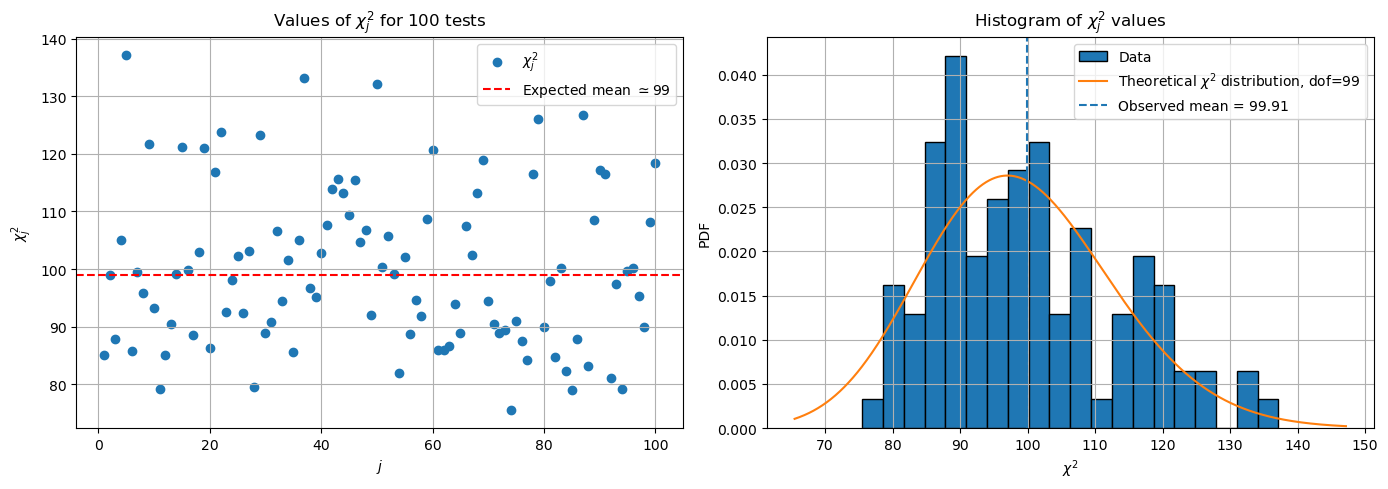

Mean of the 100 chi-square values: 99.91


In [4]:
chi2_values = chi2_data["Chi_2"].values
j = np.arange(1, len(chi2_values)+1)

dof = 99
expected_mean = dof
observed_mean = chi2_values.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(j, chi2_values, marker='o', label=r"$\chi^2_j$")
axes[0].axhline(expected_mean, color='r', linestyle='--', label=r"Expected mean $\simeq 99$")
axes[0].set_xlabel(r"$j$")
axes[0].set_ylabel(r"$\chi^2_j$")
axes[0].set_title(r"Values of $\chi^2_j$ for 100 tests")
axes[0].grid(True)
axes[0].legend()

axes[1].hist(chi2_values, bins=20, density=True, edgecolor="black", label="Data")
x_chi = np.linspace(min(chi2_values)-10, max(chi2_values)+10, 1000)
axes[1].plot(x_chi, chi2.pdf(x_chi, df=dof), label=rf"Theoretical $\chi^2$ distribution, dof={dof}")
axes[1].axvline(observed_mean, linestyle='--', label=rf"Observed mean = {observed_mean:.2f}")
axes[1].set_xlabel(r"$\chi^2$")
axes[1].set_ylabel("PDF")
axes[1].set_title(r"Histogram of $\chi^2_j$ values")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean of the 100 chi-square values: {observed_mean:.2f}")


#### Comment


The values of $\chi^2_i$ fluctuate around the expected scale. Since the interval is divided into $M=100$ bins and the total number of generated values in each test is fixed to $n=10000$, the 100 bin counts are not all independent. Once the counts in 99 bins are known, the count in the last bin is determined by the condition

$$
\sum_{k=1}^{100} O_k = 10000.
$$

Therefore, the theoretical $\chi^2$ distribution has approximately

$$
\nu = M-1 = 99
$$

degrees of freedom. Since the mean value of a $\chi^2$ distribution is equal to its number of degrees of freedom, the expected mean is close to 99, i.e. of order 100.

The sequence of $\chi^2_i$ values does not have to be constant: each test uses a different set of $10^4$ pseudo-random numbers, so statistical fluctuations are expected. The relevant point is that the values are distributed around the expected order of magnitude and do not show a systematic deviation.

The histogram is reasonably compatible with the expected $\chi^2$ distribution. Since only 100 independent $\chi^2$ tests are performed, the empirical histogram is naturally rather noisy. Increasing the number of repetitions, for example by increasing `N_tests` in the C++ code, would make the histogram smoother (as shown at the end of the notebook).

Therefore, this test does not show significant evidence against the hypothesis that the generated numbers are uniformly distributed. This does not prove that the generator is perfect; it only means that, with this test and this sample size, no clear incompatibility is observed.

### N can be chosen in many ways ... what are the limitations regarding this choice?


The assignment also asks about the limits in the choice of the number of blocks $N$. The choice is not arbitrary. If the number of blocks is too small, there are too few block measurements and the uncertainty estimate becomes unstable. On the other hand, if the number of blocks is too large, each block contains too few throws and the block averages become noisy.

Another important point is the possible presence of correlations. In general Monte Carlo simulations, consecutive data may be correlated, so the block length should be larger than the correlation time. In this way, correlations are mostly averaged inside each block, and different block averages can be treated as approximately independent measurements.

In this exercise, the generated numbers are produced by a pseudo-random generator designed to reproduce independent uniform variables, so strong correlations are not expected. Therefore, using $M=10000$ total throws divided into $N=100$ blocks is a reasonable compromise: each block contains 100 throws, and there are enough blocks to estimate the progressive statistical uncertainty.

## EXERCISE 1.2


### Assignment prompt


**Exercise 01.2** - Extend the pseudo-random number generator and check the Central Limit Theorem:

1. Add two probability distributions by using the method of the inversion of the cumulative distribution to sample from a generic exponential distribution,

$$
p(x)=\lambda e^{-\lambda x}, \qquad x\in[0,+\infty),
$$

and from a generic Cauchy-Lorentz distribution,

$$
p(x)=\frac{1}{\pi}\frac{\Gamma}{(x-\mu)^2+\Gamma^2}, \qquad x\in(-\infty,+\infty).
$$

2. Make 3 pictures with the histograms obtained by filling them with $10^4$ realizations of

$$
S_N = \frac{1}{N}\sum_{i=1}^{N}x_i
$$

for $N=1,2,10,100$, where $x_i$ is sampled from a standard dice, an exponential dice with $\lambda=1$, and a Lorentzian dice with $\mu=0$ and $\Gamma=1$. Fit the case $N=100$ with a Gaussian for the standard and exponential dice, and with a Cauchy-Lorentz distribution for the last case.


### Method

Starting from a uniform random number $s\in[0,1)$, the inversion of the cumulative distribution function allows one to sample from a chosen distribution. If $F(x)$ is the cumulative distribution, one sets

$$
s = F(x) \qquad \Rightarrow \qquad x = F^{-1}(s).
$$

For the exponential distribution this gives

$$
x = -\frac{1}{\lambda}\ln(1-s),
$$

while for the Cauchy-Lorentz distribution it gives

$$
x = \mu + \Gamma \tan\left[\pi\left(s-\frac{1}{2}\right)\right].
$$

In the C++ random-number generator these methods were implemented as:

```cpp
double Random :: Exp(double lambda) {
   double s = Rannyu();
   return -log(1.-s)/lambda;
}

double Random :: Lorentz(double mu, double gamma) {
   double s = Rannyu();
   return mu + gamma*tan(M_PI*(s-0.5));
}
```

To check the Central Limit Theorem qualitatively, $10^4$ values of

$$
S_N = \frac{1}{N}\sum_{i=1}^{N}x_i
$$

are generated for $N=1,2,10,100$.

For each distribution and for each value of $N$, the histogram contains $10^4$ values of $S_N$. Each value of $S_N$ is the average of $N$ independent random variables. Therefore, the histogram for $N=100$, for example, contains $10^4$ values of $S_{100}$, but its construction requires $10^4 \times 100$ elementary random extractions.

If the variables are independent and have finite mean and variance, the distribution of $S_N$ tends to a Gaussian as $N$ increases. This is expected for the uniform and exponential cases. The Cauchy-Lorentz distribution behaves differently: its tails are too heavy for the mean and the variance to be finite, so the standard Central Limit Theorem does not apply. In fact, the Cauchy-Lorentz distribution is stable under sums, meaning that the average of Cauchy-Lorentz variables is still Cauchy-Lorentz distributed, with the same center and width parameters.



### 1.2.1) Standard dice: uniform distribution in $[0,1)$


#### Results


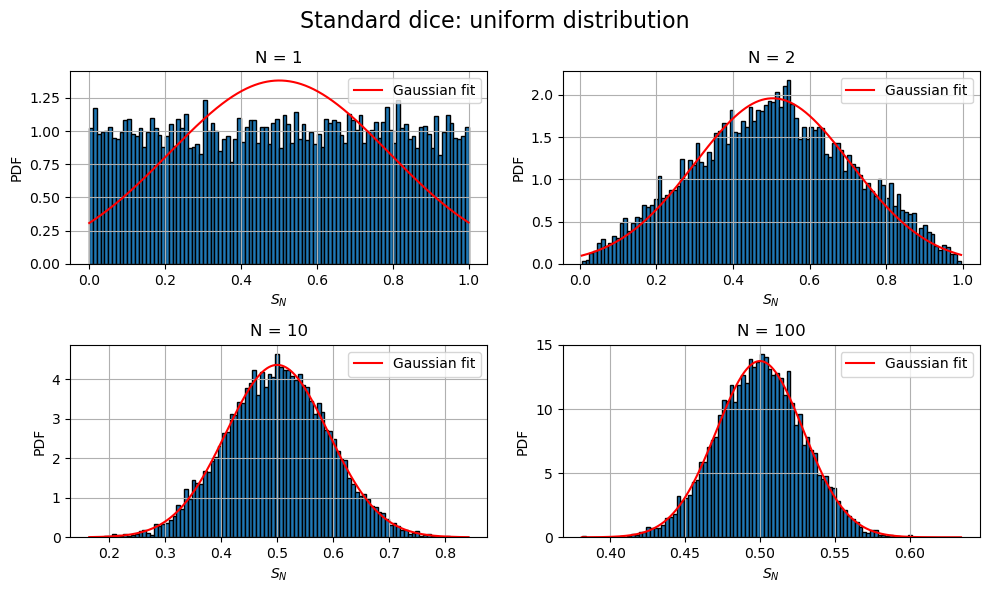

In [5]:
cols = ["Sum_uniform_1", "Sum_uniform_2", "Sum_uniform_10", "Sum_uniform_100"]
titles = ["N = 1", "N = 2", "N = 10", "N = 100"]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(data_2[col], bins=100, density=True, edgecolor="black")
    
    mu, sigma = norm.fit(data_2[col])
    x_fit = np.linspace(data_2[col].min(), data_2[col].max(), 1000)
    axes[i].plot(x_fit, norm.pdf(x_fit, mu, sigma), "r-", lw=1.5, label="Gaussian fit")
    
    axes[i].set_xlabel(r"$S_N$")
    axes[i].set_ylabel("PDF")
    axes[i].set_title(titles[i])
    axes[i].legend()
    axes[i].grid(True)

fig.suptitle("Standard dice: uniform distribution", fontsize=16)
plt.tight_layout()
plt.show()


#### Comment


For $N=1$ the original uniform distribution is recovered. As $N$ increases, the distribution of the averages $S_N$ becomes more concentrated around the expected value $\langle r\rangle=1/2$ and progressively approaches a Gaussian shape. This behavior is consistent with the Central Limit Theorem, because the uniform distribution has finite mean and finite variance.


### 1.2.2) Exponential dice with $\lambda=1$


#### Results


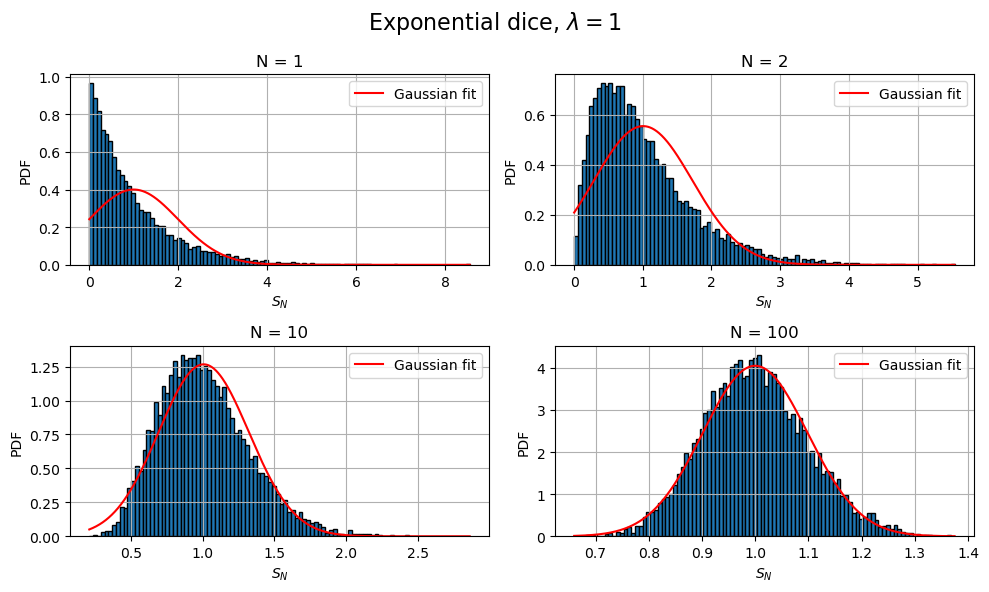

In [6]:
cols = ["Sum_exponential_1", "Sum_exponential_2", "Sum_exponential_10", "Sum_exponential_100"]
titles = ["N = 1", "N = 2", "N = 10", "N = 100"]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(data_2[col], bins=100, density=True, edgecolor="black")
    
    mu, sigma = norm.fit(data_2[col])
    x_fit = np.linspace(data_2[col].min(), data_2[col].max(), 1000)
    axes[i].plot(x_fit, norm.pdf(x_fit, mu, sigma), "r-", lw=1.5, label="Gaussian fit")
    
    axes[i].set_xlabel(r"$S_N$")
    axes[i].set_ylabel("PDF")
    axes[i].set_title(titles[i])
    axes[i].legend()
    axes[i].grid(True)

fig.suptitle(r"Exponential dice, $\lambda=1$", fontsize=16)
plt.tight_layout()
plt.show()


#### Comment


For $N=1$ the distribution is strongly asymmetric, as expected for an exponential distribution. Increasing $N$, the averages $S_N$ become more symmetric and concentrate around the theoretical mean $1/\lambda=1$. The Central Limit Theorem applies here as well, since the exponential distribution has finite mean and variance.


### 1.2.3) Lorentzian dice with $\mu=0$ and $\Gamma=1$


#### Results


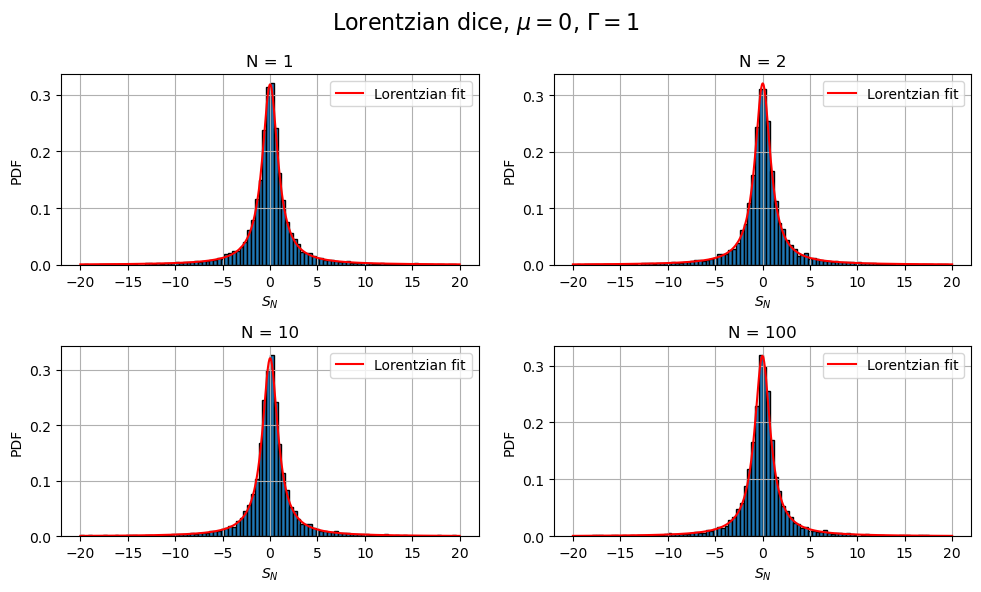

In [7]:
cols = ["Sum_lorentzian_1", "Sum_lorentzian_2", "Sum_lorentzian_10", "Sum_lorentzian_100"]
titles = ["N = 1", "N = 2", "N = 10", "N = 100"]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for i, col in enumerate(cols):
    xmin = -20
    xmax = 20

    axes[i].hist(data_2[col], bins=100, range=(xmin, xmax), density=True, edgecolor="black")

    mu, gamma = cauchy.fit(data_2[col])
    x_fit = np.linspace(xmin, xmax, 1000)
    axes[i].plot(x_fit, cauchy.pdf(x_fit, mu, gamma), "r-", lw=1.5, label="Lorentzian fit")
    
    axes[i].set_xlabel(r"$S_N$")
    axes[i].set_ylabel("PDF")
    axes[i].set_title(titles[i])
    axes[i].legend()
    axes[i].grid(True)

fig.suptitle(r"Lorentzian dice, $\mu=0$, $\Gamma=1$", fontsize=16)
plt.tight_layout()
plt.show()


#### Comment


The Lorentzian case is different. The Cauchy-Lorentz distribution does not have a finite mean or variance in the usual sense, so the standard assumptions of the Central Limit Theorem are not satisfied. Even for $N=100$, the distribution of $S_N$ does not converge to a Gaussian. It remains well described by a Lorentzian distribution, consistently with the stability property of the Cauchy distribution under sums of independent variables.


## EXERCISE 1.3


### Assignment prompt


**Exercise 01.3** - Simulate Buffon's experiment.

A needle of length $L$ is thrown at random onto a horizontal plane ruled with straight lines a distance $d$ apart, with $d>L$. The probability $P$ that the needle intersects one of the lines is

$$
P = \frac{2L}{\pi d}.
$$

This can be used to estimate $\pi$. If the needle is thrown $N_{thr}$ times and intersects a line $N_{hit}$ times, then

$$
\pi = \frac{2L}{Pd} = \lim_{N_{thr}\to\infty}\frac{2LN_{thr}}{N_{hit}d}.
$$

Make a picture of the estimation of $\pi$ and its uncertainty with a large number of throws $M$ as a function of the number of blocks $N$. If possible, do not use $\pi$ to evaluate $\pi$.


### Method


A needle of length $L=1$ is simulated to be thrown onto a plane with parallel lines separated by a distance $d=1.2$, so that the condition $d>L$ is satisfied. For each throw, the distance $x$ of the center of the needle from the nearest line is generated, with $0\leq x\leq d/2$. The orientation angle $\theta$ is measured with respect to the direction of the parallel lines.

The needle intersects a line if the perpendicular half-projection of the needle is larger than this distance:

$$
x \leq \frac{L}{2}\sin\theta.
$$

A possible way to generate the orientation of the needle would be to extract an angle uniformly in the interval $[0,\pi/2]$. However, this would require using the value of $\pi$ explicitly, while the goal of the exercise is precisely to estimate $\pi$.

For this reason, the angle is not generated directly. Instead, a random point $(u,v)$ is generated in the first quadrant of the unit circle. The direction of the vector from the origin to this point defines a random orientation, and only the sine of the angle is needed in the intersection condition. Therefore, $\sin\theta$ is computed directly as

$$
\sin\theta = \frac{v}{\sqrt{u^2+v^2}}.
$$

The main C++ structure is:

```cpp
double x = rnd.Rannyu(0.0, d/2.0);

double x_circ, y_circ, r;
for(;;){
   x_circ = rnd.Rannyu();
   y_circ = rnd.Rannyu();
   r = sqrt(x_circ*x_circ + y_circ*y_circ);

   if(r <= 1.0 && r != 0.0) break;
}

double sin_theta = y_circ/r;

if(x <= (L/2.0)*sin_theta){
   hit++;
}
```

The estimate of $\pi$ is then obtained from the observed hit frequency by using

$$
\pi \simeq \frac{2L N_{\mathrm{thr}}}{N_{\mathrm{hit}}d}.
$$

As in the previous exercises, data blocking is used to obtain a progressive estimate and its statistical uncertainty. In this simulation, $N_{\mathrm{thr}}=10000$ needle throws are divided into $N=100$ blocks, so that each block contains 100 throws. For each block, the hit frequency is used to compute one block estimate of $\pi$, and the progressive average is then built from these block estimates.

### Progressive estimate of $\pi$


#### Results


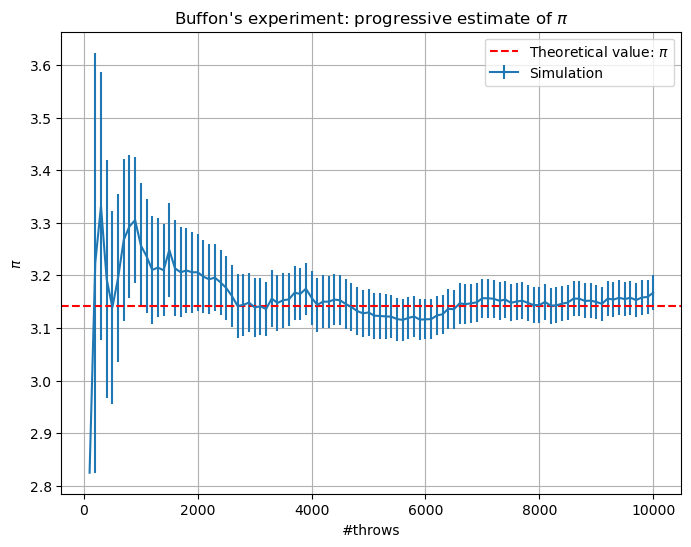

In [8]:
N_throws = 10000
N_blocks = 100
throws_per_block = N_throws // N_blocks

x_blocks = np.arange(1, N_blocks+1) * throws_per_block

plt.figure(figsize=(8, 6))
plt.title(r"Buffon's experiment: progressive estimate of $\pi$")
plt.errorbar(x_blocks, data_3["Progressive_pi"], yerr=data_3["Progressive_pi_error"], label="Simulation")
plt.axhline(y=np.pi, color='r', linestyle='--', label=r'Theoretical value: $\pi$')
plt.xlabel('#throws')
plt.ylabel(r'$\pi$')
plt.grid(True)
plt.legend()
plt.show()


#### Comment


The final estimate of $\pi$ is compatible with the exact value within the statistical uncertainty.

The choice of $d$ is important. If $d$ were much larger than $L$, the probability of intersection would become small, and many more throws would be needed to obtain a precise estimate. This is why the condition $d>L$ is required, but choosing $d\gg L$ would be inefficient.


## Additional check: increasing the number of $\chi^2$ tests

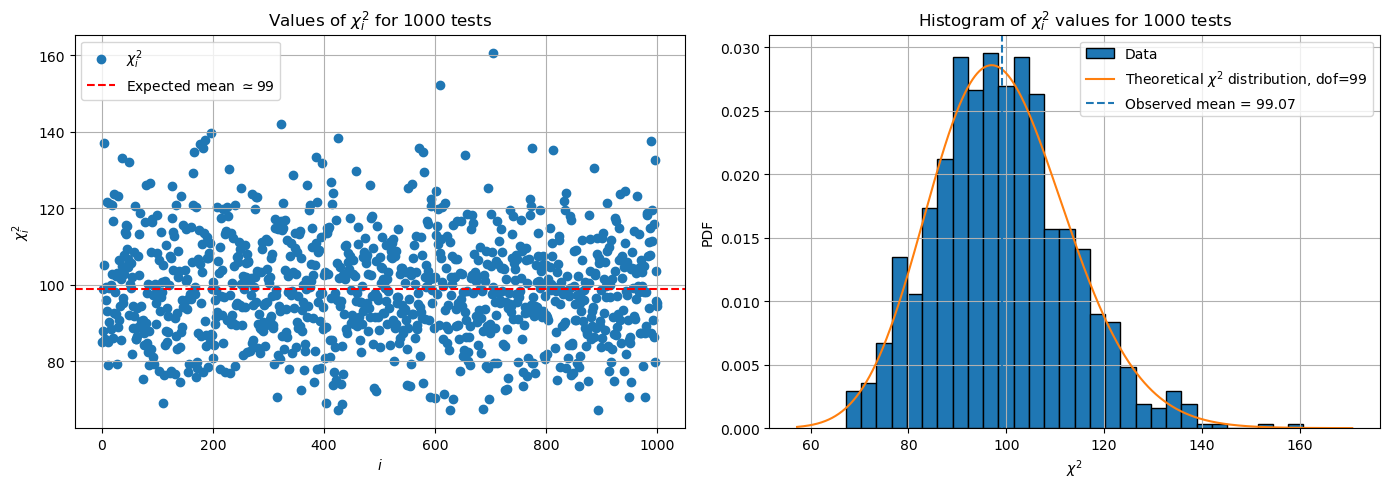

Mean of the 1000 chi-square values: 99.07


In [9]:
chi2_values = chi2_additional_data["Chi_2"].values
i = np.arange(1, len(chi2_values)+1)

dof = 99
expected_mean = dof
observed_mean = chi2_values.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(i, chi2_values, marker='o', label=r"$\chi^2_i$")
axes[0].axhline(expected_mean, color='r', linestyle='--', label=r"Expected mean $\simeq 99$")
axes[0].set_xlabel(r"$i$")
axes[0].set_ylabel(r"$\chi^2_i$")
axes[0].set_title(r"Values of $\chi^2_i$ for 1000 tests")
axes[0].grid(True)
axes[0].legend()

axes[1].hist(chi2_values, bins=30, density=True, edgecolor="black", label="Data")
x_chi = np.linspace(min(chi2_values)-10, max(chi2_values)+10, 1000)
axes[1].plot(x_chi, chi2.pdf(x_chi, df=dof), label=rf"Theoretical $\chi^2$ distribution, dof={dof}")
axes[1].axvline(observed_mean, linestyle='--', label=rf"Observed mean = {observed_mean:.2f}")
axes[1].set_xlabel(r"$\chi^2$")
axes[1].set_ylabel("PDF")
axes[1].set_title(r"Histogram of $\chi^2_i$ values for 1000 tests")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean of the 1000 chi-square values: {observed_mean:.2f}")